# Dev notebook — ext_clustering.py (Tầng 1: K-means)

Notebook này **import thẳng từ `ext_clustering.py`** (không định nghĩa lại). Cần có `/tmp/aqi` (output Pha 2) trước — chạy `phase1_clean.py` rồi `phase2_aqi.py`, hoặc 2 notebook dev tương ứng.

Sửa `ext_clustering.py` xong, chạy lại cell là thấy ngay nhờ `%autoreload 2`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from ext_clustering import (
    build_city_month_features, fit_kmeans, fit_gmm, fit_bisecting_kmeans,
    compare_clustering_algorithms, pick_best_k, _assemble_and_scale,
    FEATURE_COLS, K_CANDIDATES,
)

spark = (
    SparkSession.builder.appName("ext_clustering_dev").master("local[*]")
    .config("spark.sql.session.timeZone", "UTC")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")

AQI_INPUT = "/tmp/aqi"  # output cua phase2_aqi.py

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/14 22:20:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Bước 0 — đọc output Pha 2

In [2]:
df = spark.read.parquet(AQI_INPUT)
print("so dong:", df.count())
df.select("city", "country", "ts_utc", "pm2_5", "pm10", "o3", "no2", "lat", "lon").show(5)

so dong: 10800


+-----------+-------+-------------------+-----+-----+-----+----+-------+--------+
|       city|country|             ts_utc|pm2_5| pm10|   o3| no2|    lat|     lon|
+-----------+-------+-------------------+-----+-----+-----+----+-------+--------+
|Thu Dau Mot|     VN|2026-07-11 00:00:00| 5.82| 8.47| 18.5|3.36|10.9804|106.6519|
|Thu Dau Mot|     VN|2026-07-11 01:00:00| 4.18| 5.21|32.27|3.88|10.9804|106.6519|
|Thu Dau Mot|     VN|2026-07-11 02:00:00| 4.74| 6.64|31.36|6.74|10.9804|106.6519|
|Thu Dau Mot|     VN|2026-07-11 03:00:00| 4.95|  7.3| 45.0| 1.2|10.9804|106.6519|
|Thu Dau Mot|     VN|2026-07-11 04:00:00|  2.3|4.945|55.07|2.26|10.9804|106.6519|
+-----------+-------+-------------------+-----+-----+-----+----+-------+--------+
only showing top 5 rows



## Bước 1 — `build_city_month_features()`: gộp theo (city, tháng)

Lưu ý: gộp theo THÁNG LỊCH (1-12), không phải năm-tháng — cố tình bắt pattern mùa vụ qua nhiều năm.

In [3]:
features = build_city_month_features(df)
print("so dong (city x thang):", features.count())
features.orderBy("city", "month").show(20, truncate=False)

so dong (city x thang): 20


+----------------+-------+-----+------------------+------------------+------------------+------------------+------------------+------------------+-------+
|city            |country|month|avg_pm2_5         |avg_pm10          |avg_o3            |avg_no2           |lat               |lon               |n_hours|
+----------------+-------+-----+------------------+------------------+------------------+------------------+------------------+------------------+-------+
|Hanoi           |VN     |6    |17.003833333333333|24.030611111111117|32.42743055555555 |14.287972222222223|21.027799999999967|105.83419999999983|384    |
|Hanoi           |VN     |7    |29.078448275862087|40.680143678160896|32.40385057471264 |14.130933908045971|21.027799999999917|105.83420000000001|744    |
|Hanoi           |VN     |8    |12.138132183908045|17.010201149425285|32.23120689655172 |14.252780172413793|21.02779999999992 |105.83420000000021|744    |
|Hanoi           |VN     |9    |22.183636363636367|31.158750000000005|

## Bước 2 — chọn k bằng silhouette score

In [4]:
scaled = _assemble_and_scale(features)
best_k = pick_best_k(scaled, k_candidates=K_CANDIDATES)

26/09/14 22:20:24 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/09/14 22:20:24 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS



=== Silhouette score theo k — KMeans (càng gần 1 càng tốt) ===
  k=2: 0.7127
  k=3: 0.4516
  k=4: 0.5138
  k=5: 0.4848
  k=6: 0.4569
-> Chọn k=2 (silhouette cao nhất)



## Bước 3 — `fit_kmeans()` với k tốt nhất, xem gán cụm

In [5]:
result, model, k, silhouette = fit_kmeans(features, k=best_k)
print(f"k={k}, silhouette={silhouette:.4f}")
result.select("city", "month", "avg_pm2_5", "avg_pm10", "avg_o3", "avg_no2", "cluster").orderBy("cluster", "city").show(50, truncate=False)

k=2, silhouette=0.7127
+----------------+-----+------------------+------------------+------------------+------------------+-------+
|city            |month|avg_pm2_5         |avg_pm10          |avg_o3            |avg_no2           |cluster|
+----------------+-----+------------------+------------------+------------------+------------------+-------+
|New Delhi       |7    |70.96990755007704 |100.11591679506934|32.36963020030818 |36.305254237288146|0      |
|New Delhi       |8    |46.05866187050359 |64.95256115107914 |32.272661870503605|36.66847482014388 |0      |
|New Delhi       |9    |75.62291666666665 |106.60472222222221|32.67803819444444 |38.29180555555555 |0      |
|New Delhi       |6    |52.41366071428573 |73.87892857142859 |32.42363095238096 |35.98361607142858 |0      |
|Hanoi           |8    |12.138132183908045|17.010201149425285|32.23120689655172 |14.252780172413793|1      |
|Hanoi           |9    |22.183636363636367|31.158750000000005|31.61200757575758 |12.964507575757573|1    

## Bước 4 — trực quan hoá cụm (avg_pm2_5 vs avg_pm10, tô màu theo cluster)

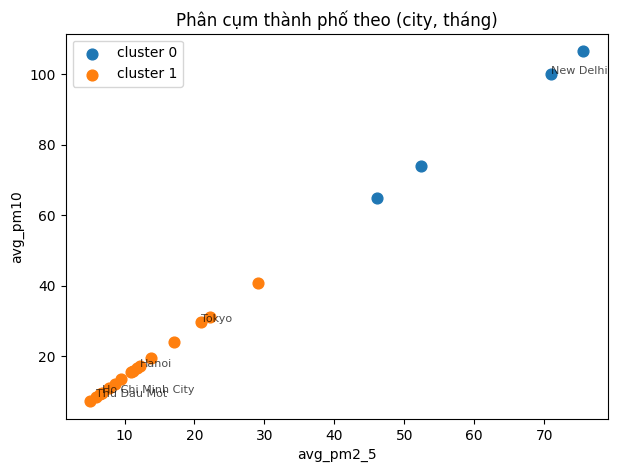

In [6]:
import matplotlib.pyplot as plt

pdf = result.select("city", "month", "avg_pm2_5", "avg_pm10", "cluster").toPandas()

fig, ax = plt.subplots(figsize=(7, 5))
for c in sorted(pdf["cluster"].unique()):
    sub = pdf[pdf["cluster"] == c]
    ax.scatter(sub["avg_pm2_5"], sub["avg_pm10"], label=f"cluster {c}", s=60)
for _, row in pdf.drop_duplicates("city").iterrows():
    ax.annotate(row["city"], (row["avg_pm2_5"], row["avg_pm10"]), fontsize=8, alpha=0.7)
ax.set_xlabel("avg_pm2_5")
ax.set_ylabel("avg_pm10")
ax.set_title("Phân cụm thành phố theo (city, tháng)")
ax.legend()
plt.show()

## Bước 5 — Tầng 2: so sánh GMM / Bisecting K-means với K-means (Tầng 1)

Chạy cả 3 thuật toán, mỗi thuật toán tự chọn k tốt nhất bằng silhouette, rồi chọn thuật toán thắng — không chọn bừa GMM hay Bisecting K-means.

In [7]:
best_name, best_result, best_model, best_k, best_silhouette = compare_clustering_algorithms(features)
print(f"Thắng: {best_name} (k={best_k}, silhouette={best_silhouette:.4f})")

best_result.select("city", "month", "avg_pm2_5", "avg_pm10", "cluster").orderBy("cluster", "city").show(50, truncate=False)


########## So sánh thuật toán phân cụm (Tầng 1 vs Tầng 2) ##########



=== Silhouette score theo k — KMeans (càng gần 1 càng tốt) ===
  k=2: 0.7127
  k=3: 0.4516
  k=4: 0.5138
  k=5: 0.4848
  k=6: 0.4569
-> Chọn k=2 (silhouette cao nhất)



26/09/14 22:20:40 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK



=== Silhouette score theo k — GaussianMixture (càng gần 1 càng tốt) ===
  k=2: 0.3287
  k=3: 0.3041
  k=4: -0.0868
  k=5: -0.0229
  k=6: -0.2208
-> Chọn k=2 (silhouette cao nhất)




=== Silhouette score theo k — BisectingKMeans (càng gần 1 càng tốt) ===
  k=2: 0.3287
  k=3: 0.1142
  k=4: 0.4520
  k=5: 0.2767
  k=6: 0.3500
-> Chọn k=4 (silhouette cao nhất)



=== Tổng kết ===
  KMeans          : k=2, silhouette=0.7127
  GaussianMixture : k=2, silhouette=0.3287
  BisectingKMeans : k=4, silhouette=0.4520
-> Thắng: KMeans (k=2, silhouette=0.7127)
######################################################################

Thắng: KMeans (k=2, silhouette=0.7127)
+----------------+-----+------------------+------------------+-------+
|city            |month|avg_pm2_5         |avg_pm10          |cluster|
+----------------+-----+------------------+------------------+-------+
|New Delhi       |7    |70.96990755007704 |100.11591679506934|0      |
|New Delhi       |8    |46.05866187050359 |64.95256115107914 |0      |
|New Delhi       |9    |75.62291666666665 |106.60472222222221|0      |
|New Delhi       |6    |52.41366071428573 |73.87892857142859 |0      |
|Hanoi           |8    |12.138132183908045|17.010201149425285|1      |
|Hanoi           |9    |22.183636363636367|31.158750000000005|1      |
|Hanoi           |7    |29.078448275862087|40.680143678160896|

## Ghi chú

- Kết quả trên chỉ chạy trên `data/samples/` (~4 tháng, 5 trạm) — CHƯA phải số liệu chính thức cho báo cáo. Khi Người A có data thật (200 trạm x 3-5 năm), chạy lại toàn bộ pipeline rồi mới lấy số chính thức.
- Notebook này chỉ để đọc/hiểu/debug — sửa logic thì sửa `ext_clustering.py`.